**Используемые фичи:**
- **Year** – Сезон (год проведения гонки)
- **Race** – Название Гран-при
- **Driver** – Код гонщика
- **LapNumber** – Номер круга в пределах гонки
- **Position** – Позиция гонщика на данном круге
- **LapTime (s)** – Время круга в секундах
- **Stint** – Номер stint'а (отрезка между пит-стопами)
- **TyreLife** – Количество кругов на текущем комплекте шин
- **Normalized_TyreLife** – Нормированный износ шин в пределах stint'а
- **Compound_Encoded** – Кодированный тип состава шин (например, мягкие, средние, жесткие)
- **LapTime_Delta** – Изменение времени круга относительно предыдущего круга
- **Cumulative_Degradation** – Накопленная деградация шин (падение производительности)
- **Position_Change** – Изменение позиции (выигрыш/потеря) относительно предыдущего круга
- **RaceProgress** – Доля пройденной гонки (от 0 до 1)
- **PitStop** – Была ли проведена остановка в боксах на этом круге (0/1)
- **PitNextLap** – Целевая переменная: совершит ли гонщик пит-стоп на следующем круге (0/1)

In [192]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os.path

file_path = "f1_strategy_dataset_v4.csv"

if os.path.exists(file_path):
  df = pd.read_csv(file_path)
else:
  df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "aadigupta1601/f1-strategy-dataset-pit-stop-prediction",
    file_path,
  )
  df.to_csv("../data/raw/f1_strategy_dataset_v4.csv")
df.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


1. **Анализ датасета**

In [193]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  str    
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  str    
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  str    
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101371 non-null  int64  
 13  RaceProgress            101371 non-null  float64
 14  Normalized_TyreLife     101371 

C:\Users\suhar\AppData\Local\Temp\ipykernel_1384\1723276852.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include = [object]).columns.to_list()


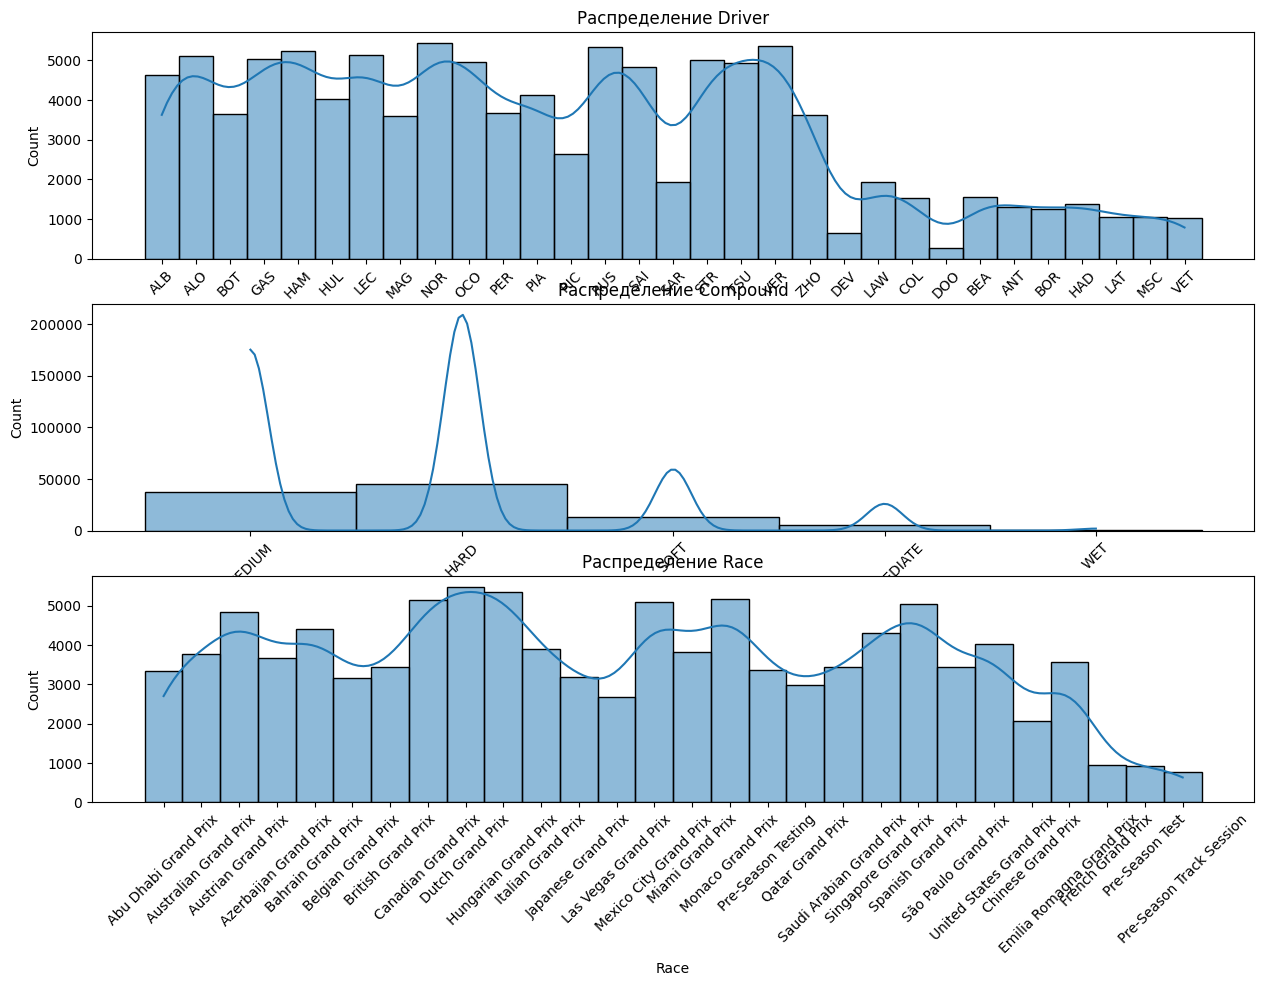

In [194]:
plt.figure(figsize=(15, 10))
hist_num = 3
str_cols = df.select_dtypes(include = [object]).columns.to_list()

for i, column in enumerate(str_cols):
  if isinstance(df[column][0], str):
    plt.subplot(len(str_cols), 1, i+1)
    sns.histplot(data=df, x=column, bins=30, kde=True)
    plt.title(f"Распределение {column}")
    plt.xticks(rotation=45)
plt.show()

In [195]:
print("Проверка баланса классов:")
positive = df['PitNextLap'][df['PitNextLap'] == 1].count()
negative = df['PitNextLap'][df['PitNextLap'] == 0].count()
print(f"Positive: {positive}, Negative: {negative}")

Проверка баланса классов:
Positive: 25829, Negative: 75542


Text(0.5, 1.0, 'Матрица корреляции')

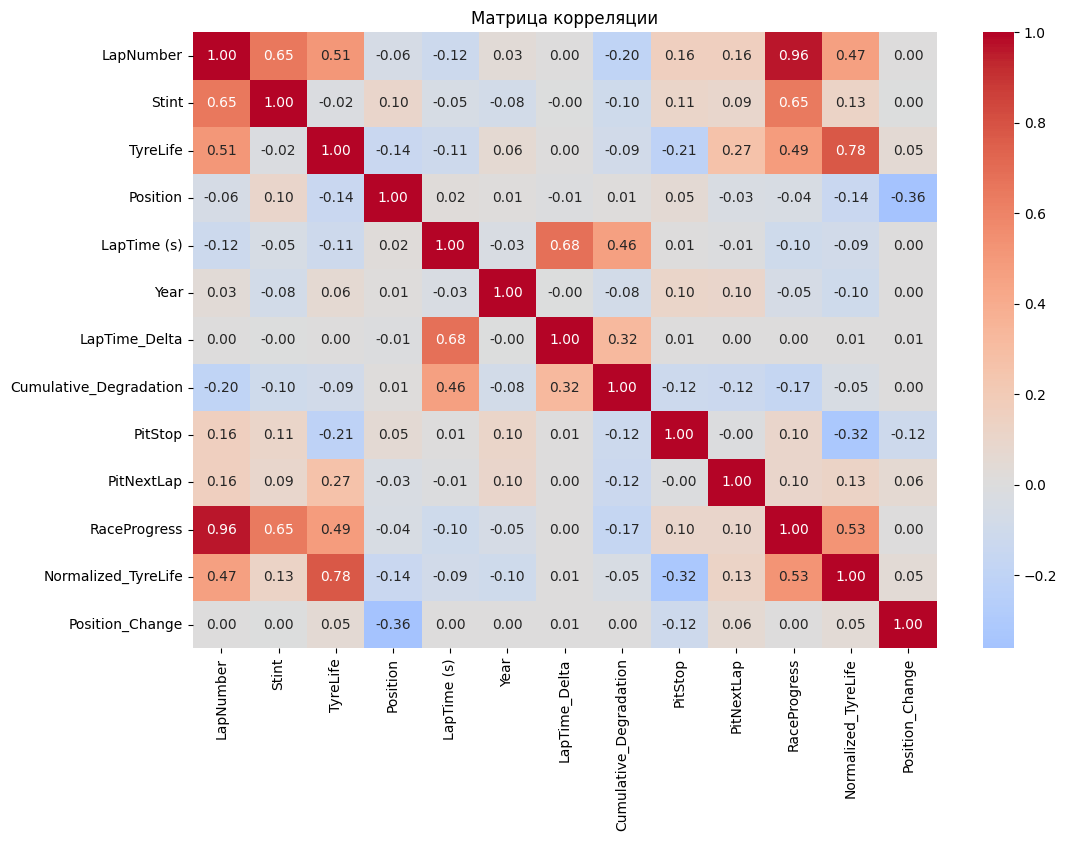

In [196]:
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Матрица корреляции")

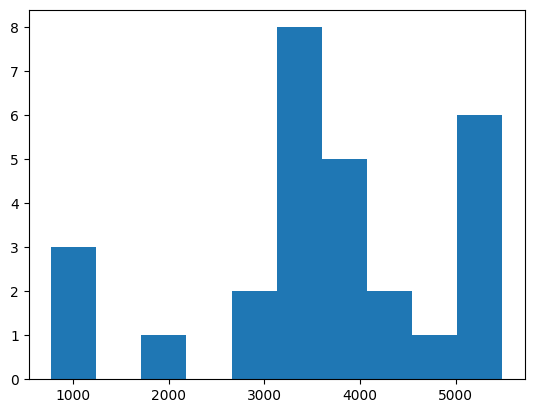

In [197]:
pit_by_track = df.groupby('Race')['PitNextLap'].count()
plt.hist(pit_by_track)
plt.show()

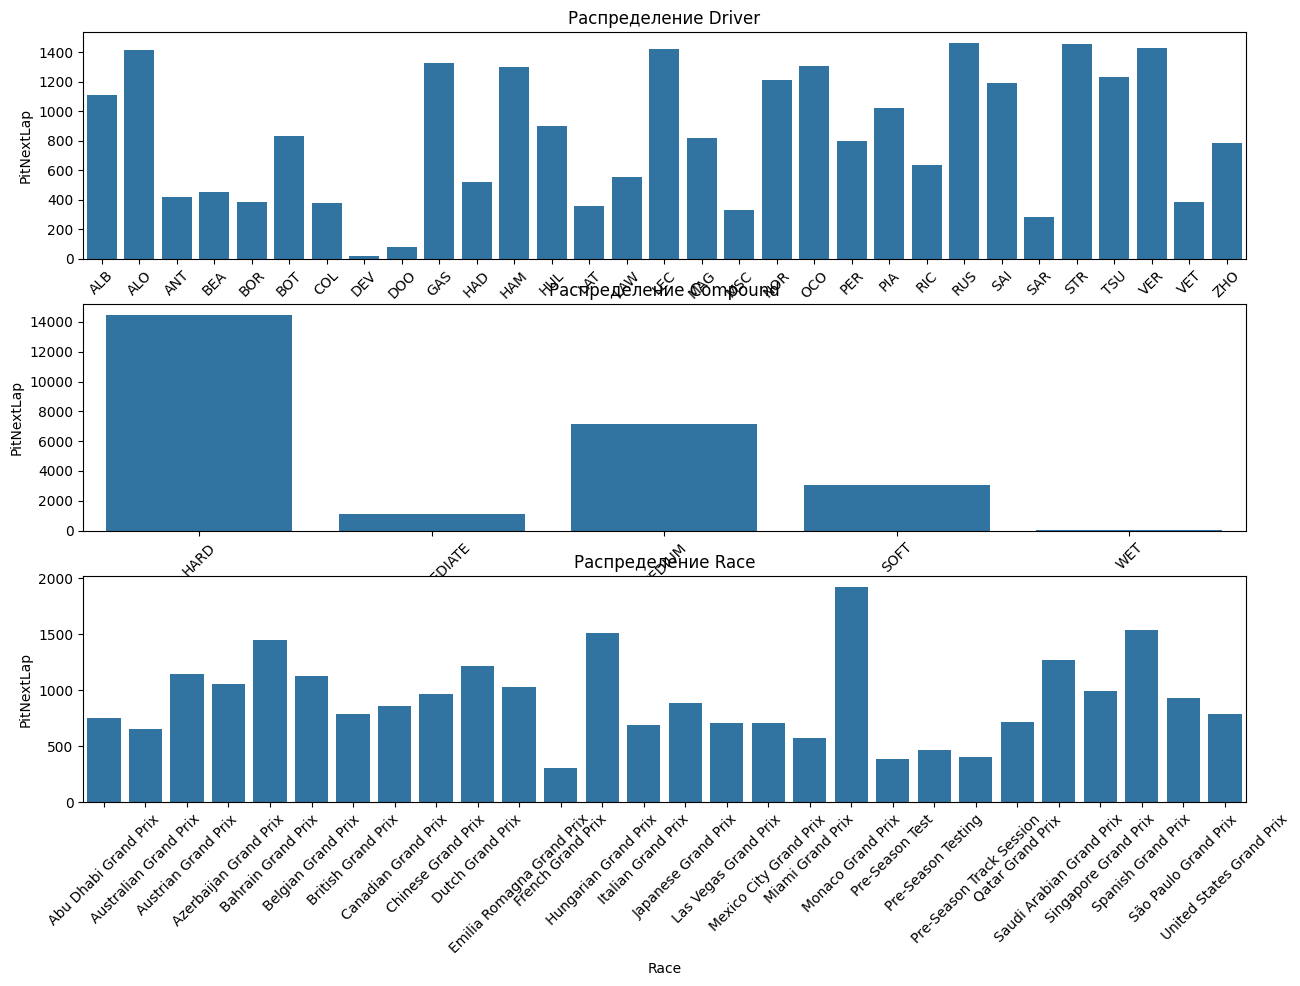

In [198]:
plt.figure(figsize=(15, 10))
hist_num = len(df.columns)

for i, column in enumerate(str_cols):
  if isinstance(df[column][0], str):
    pit_feature = df.groupby(column)['PitNextLap'].sum().reset_index()
    
    plt.subplot(len(str_cols), 1, i + 1)
    sns.barplot(data=pit_feature, x=column, y ='PitNextLap')
    plt.title(f"Распределение {column}")
    plt.xticks(rotation=45)
plt.show()

In [199]:
df = df.drop_duplicates()
df = df.drop(['TyreLife', 'LapNumber'], axis=1)

In [200]:
df_encoded = pd.get_dummies(df, columns=str_cols, drop_first=False)

In [201]:
df.head(20)

,Driver,Compound,Stint,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,MEDIUM,1,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,MEDIUM,1,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,MEDIUM,1,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,MEDIUM,1,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,MEDIUM,1,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0
5,ALB,MEDIUM,1,18,91.491,Abu Dhabi Grand Prix,2023,0.069,-9.134,0,0,0.103448,0.411765,0.0
6,ALB,MEDIUM,1,18,91.438,Abu Dhabi Grand Prix,2023,-0.053,-9.187,0,0,0.120690,0.470588,0.0
7,ALB,MEDIUM,1,17,91.580,Abu Dhabi Grand Prix,2023,0.142,-9.045,0,0,0.137931,0.529412,1.0
8,ALB,MEDIUM,1,17,91.644,Abu Dhabi Grand Prix,2023,0.064,-8.981,0,0,0.155172,0.588235,0.0
9,ALB,MEDIUM,1,17,91.978,Abu Dhabi Grand Prix,2023,0.334,-8.647,0,0,0.172414,0.647059,0.0


In [202]:
df_encoded.to_csv("../data/processed/f1_strategy_dataset_v4_processed.csv")